In [438]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'


In [439]:
def get_sorted_columns(data, name='train-top5-acc'):
    columns = [col for col in data.columns if name in col and "__" not in col]
    index = [int(column.split(" - ")[0].split('-')[-1])for column in columns]

    zipped_value = zip(columns,index)
    sorted_zipped_value = sorted(zipped_value, key=lambda x:x[1])

    sorted_columns, sorted_index = zip(*sorted_zipped_value)

    return sorted_columns

def get_concatenated_data(data, name='train-top5-acc'):

    sorted_columns = get_sorted_columns(data,name)
    concatenated_values = pd.concat([data[column] for column in sorted_columns]).dropna()

    return concatenated_values

def remove_epoch_overlap_single(metric_series, vanilla_training):
    cleaned_epoch_indices = []

    for key in vanilla_training.keys():
        run_info = vanilla_training[key]

        if len(cleaned_epoch_indices) == 0:
            for value in range(run_info['start'],run_info['end']+ 1 - run_info['remove']):
                cleaned_epoch_indices.append(value)
        else:
            total_cleaned_epochs = len(cleaned_epoch_indices)
            start_info = run_info['start']
            skip_values = total_cleaned_epochs - start_info + 1

            for value in range(total_cleaned_epochs + skip_values - 1 - run_info['remove'], run_info['end'] + skip_values - run_info['remove']):
                cleaned_epoch_indices.append(value)
            
    # Convert to list or numpy array if it's a Series
    if isinstance(metric_series, pd.Series):
        metric_series = metric_series.to_numpy()

    return [metric_series[i] for i in cleaned_epoch_indices]


def merge_data(all_data_points, merge_data_points, merge_info):

    merged_values = all_data_points

    for key in merge_info.keys():
        start_value = merge_info[key]['start']
        
        if start_value > len(all_data_points):

            merged_values = all_data_points + merge_data_points
        else:

            merged_values = merged_values[:start_value] + merge_data_points

    return merged_values

### Full Model Run Preprocessing (Full Training 300 epochs)

In [440]:
# Load the CSV file
train_top1_acc = pd.read_csv("exp_base/train_top1_acc.csv")
train_top5_acc = pd.read_csv("exp_base/train_top5_acc.csv")

valid_top1_acc = pd.read_csv("exp_base/valid_top1_acc.csv")
valid_top5_acc = pd.read_csv("exp_base/valid_top5_acc.csv")

train_loss = pd.read_csv("exp_base/train_loss.csv")
train_epoch_time = pd.read_csv("exp_base/epoch_time.csv")


In [441]:
train_top5_all = get_concatenated_data(train_top5_acc, 'train-top5-acc')
train_top1_all = get_concatenated_data(train_top1_acc, 'train-top1-acc')
valid_top5_all = get_concatenated_data(valid_top5_acc, 'top5_val_acc')
valid_top1_all = get_concatenated_data(valid_top1_acc, 'top1_val_acc')
train_loss_all = get_concatenated_data(train_loss, 'loss')
train_epoch_time_all = get_concatenated_data(train_epoch_time,'epoch_time')

In [442]:
vanilla_training = {
    1: {'start' : 0, 'end': 57, 'remove':0},
    2: {'start' : 56, 'end': 113, 'remove':0},
    3: {'start' : 111, 'end': 168, 'remove':0},
    4: {'start' : 166, 'end': 222, 'remove':0},
    5: {'start' : 221, 'end': 280, 'remove':0},
    6: {'start' : 281, 'end': 299, 'remove':0},
    }

train_top5_all = remove_epoch_overlap_single(train_top5_all, vanilla_training)
train_top1_all = remove_epoch_overlap_single(train_top1_all, vanilla_training)
valid_top5_all = remove_epoch_overlap_single(valid_top5_all, vanilla_training)
valid_top1_all = remove_epoch_overlap_single(valid_top1_all, vanilla_training)
train_loss_all = remove_epoch_overlap_single(train_loss_all, vanilla_training)
train_epoch_time_all = remove_epoch_overlap_single(train_epoch_time_all, vanilla_training)
train_epoch_time_all = [value + 125 for value in train_epoch_time_all]


In [443]:
def remove_overlap(data, different_runs, final_merge, name='', run_start_idx = 51):
    cleaned_epoch_indices = []
    stitched_range = set()  # track all epochs we've already included

    sorted_columns = get_sorted_columns(data, name)

    for index, column in enumerate(sorted_columns):
        selected_data = list(data[column].dropna().values)
        start, end = different_runs[index]

        # Build corresponding epoch indices for this run
        epoch_indices = list(range(start, end + 1))

        # Filter out epochs already included
        new_epochs = [ep for ep in epoch_indices if ep not in stitched_range]

        # Map back into selected_data (keep alignment)
        keep_count = len(new_epochs)
        if keep_count > 0:
            # Align from the right: keep the last `keep_count` values
            selected_data = selected_data[-keep_count:]
            cleaned_epoch_indices.extend(selected_data)

            # Update stitched_range
            stitched_range.update(new_epochs)

    all_value = []
    all_value.extend(final_merge[:run_start_idx])
    all_value.extend(cleaned_epoch_indices)
    
    print(f"Len of {name} is: {len(all_value)}")

    return all_value


def get_run_count(data, name='epoch'):
    sorted_columns = get_sorted_columns(data,name)
    all_runs = []
    for column in sorted_columns:
        na_dropped = data[column]
        all_runs.append((int(na_dropped.min()), int(na_dropped.max())))

    return all_runs

### Exp_1 starting at 50 (1_5)


In [444]:
# Load the CSV file
exp_1_train_t1 = pd.read_csv("exp_1_5/train_top_1.csv")
exp_1_train_t5 = pd.read_csv("exp_1_5/train_top_5.csv")

exp_1_valid_t5 = pd.read_csv("exp_1_5/valid_top_5.csv")
exp_1_valid_t1 = pd.read_csv("exp_1_5/valid_top_1.csv")

exp_1_loss = pd.read_csv("exp_1_5/loss.csv")
exp_1_epoch_time = pd.read_csv("exp_1_5/epoch_time.csv")

exp_1_epochs = pd.read_csv("exp_1_5/epochs.csv")


In [445]:
exp1_epoch_runs = get_run_count(exp_1_epochs,'epoch')
print(exp1_epoch_runs)

exp_1_full_train_t5 = remove_overlap(exp_1_train_t5, exp1_epoch_runs, train_top5_all, 'train-top5-acc')
exp_1_full_train_t1 = remove_overlap(exp_1_train_t1, exp1_epoch_runs, train_top1_all, 'train-top1-acc')
exp_1_full_valid_t5 = remove_overlap(exp_1_valid_t5, exp1_epoch_runs, valid_top5_all, 'top5_val_acc')
exp_1_full_valid_t1 = remove_overlap(exp_1_valid_t1, exp1_epoch_runs, valid_top1_all, 'top1_val_acc')
exp_1_full_loss = remove_overlap(exp_1_loss,exp1_epoch_runs, train_loss_all, 'loss')
exp_1_full_epoch_time = remove_overlap(exp_1_epoch_time,exp1_epoch_runs,train_epoch_time_all, 'epoch_time')

[(51, 83), (81, 114), (111, 124), (126, 235), (236, 299)]
Len of train-top5-acc is: 299
Len of train-top1-acc is: 299
Len of top5_val_acc is: 299
Len of top1_val_acc is: 299
Len of loss is: 299
Len of epoch_time is: 299


### Exp_2 starting at 50 (0.5_2.5)

In [446]:
# Load the CSV file
exp_2_train_t1 = pd.read_csv("exp_0.5_2.5/train_top_1.csv")
exp_2_train_t5 = pd.read_csv("exp_0.5_2.5/train_top_5.csv")

exp_2_valid_t5 = pd.read_csv("exp_0.5_2.5/valid_top_5.csv")
exp_2_valid_t1 = pd.read_csv("exp_0.5_2.5/valid_top_1.csv")

exp_2_loss = pd.read_csv("exp_0.5_2.5/loss.csv")
exp_2_epoch_time = pd.read_csv("exp_0.5_2.5/epoch_time.csv")

exp_2_epochs = pd.read_csv("exp_0.5_2.5/epochs.csv")


exp2_epoch_runs = get_run_count(exp_2_epochs,'epoch')

exp_2_full_train_t5 = remove_overlap(exp_2_train_t5, exp2_epoch_runs, train_top5_all, 'train-top5-acc')
exp_2_full_train_t1 = remove_overlap(exp_2_train_t1, exp2_epoch_runs, train_top1_all, 'train-top1-acc')
exp_2_full_valid_t5 = remove_overlap(exp_2_valid_t5, exp2_epoch_runs, valid_top5_all, 'top5_val_acc')
exp_2_full_valid_t1 = remove_overlap(exp_2_valid_t1, exp2_epoch_runs, valid_top1_all, 'top1_val_acc')
exp_2_full_loss = remove_overlap(exp_2_loss,exp2_epoch_runs, train_loss_all, 'loss')
exp_2_full_epoch_time = remove_overlap(exp_2_epoch_time,exp2_epoch_runs, train_epoch_time_all, 'epoch_time')


Len of train-top5-acc is: 299
Len of train-top1-acc is: 299
Len of top5_val_acc is: 299
Len of top1_val_acc is: 299
Len of loss is: 299
Len of epoch_time is: 299


### Exp_3 starting at 50 (0.25_1_a)

In [447]:
# Load the CSV file
exp_3_train_t1 = pd.read_csv("exp_0.25_1/train_top_1.csv")
exp_3_train_t5 = pd.read_csv("exp_0.25_1/train_top_5.csv")

exp_3_valid_t5 = pd.read_csv("exp_0.25_1/valid_top_5.csv")
exp_3_valid_t1 = pd.read_csv("exp_0.25_1/valid_top_1.csv")

exp_3_loss = pd.read_csv("exp_0.25_1/loss.csv")
exp_3_epoch_time = pd.read_csv("exp_0.25_1/epoch_time.csv")

exp_3_epochs = pd.read_csv("exp_0.25_1/epochs.csv")


exp3_epoch_runs = get_run_count(exp_3_epochs,'epoch')
print(exp3_epoch_runs)

exp_3_full_train_t5 = remove_overlap(exp_3_train_t5, exp3_epoch_runs, train_top5_all, 'train-top5-acc')
exp_3_full_train_t1 = remove_overlap(exp_3_train_t1, exp3_epoch_runs, train_top1_all, 'train-top1-acc')
exp_3_full_valid_t5 = remove_overlap(exp_3_valid_t5, exp3_epoch_runs, valid_top5_all, 'top5_val_acc')
exp_3_full_valid_t1 = remove_overlap(exp_3_valid_t1, exp3_epoch_runs, valid_top1_all, 'top1_val_acc')
exp_3_full_loss = remove_overlap(exp_3_loss,exp3_epoch_runs, train_loss_all, 'loss')
exp_3_full_epoch_time = remove_overlap(exp_3_epoch_time,exp3_epoch_runs,train_epoch_time_all, 'epoch_time')


[(51, 83), (81, 114), (111, 120), (121, 146), (146, 179), (146, 179)]
Len of train-top5-acc is: 180
Len of train-top1-acc is: 180
Len of top5_val_acc is: 180
Len of top1_val_acc is: 180
Len of loss is: 180
Len of epoch_time is: 180


### Exp_3 starting at 50 (0.25_1_b)

In [448]:
# Load the CSV file
exp_4_train_t1 = pd.read_csv("exp_0.25_1_b/train_top_1.csv")
exp_4_train_t5 = pd.read_csv("exp_0.25_1_b/train_top_5.csv")

exp_4_valid_t5 = pd.read_csv("exp_0.25_1_b/valid_top_5.csv")
exp_4_valid_t1 = pd.read_csv("exp_0.25_1_b/valid_top_1.csv")

exp_4_loss = pd.read_csv("exp_0.25_1_b/loss.csv")
exp_4_epoch_time = pd.read_csv("exp_0.25_1_b/epoch_time.csv")

exp_4_epochs = pd.read_csv("exp_0.25_1_b/epochs.csv")


exp4_epoch_runs = get_run_count(exp_4_epochs,'epoch')
print(exp4_epoch_runs)

exp_4_full_train_t5 = remove_overlap(exp_4_train_t5, exp4_epoch_runs, exp_3_full_train_t5, 'train-top5-acc', len(exp_3_full_train_t5) - 8)
exp_4_full_train_t1 = remove_overlap(exp_4_train_t1, exp4_epoch_runs, exp_3_full_train_t1, 'train-top1-acc', len(exp_3_full_train_t1) - 8)
exp_4_full_valid_t5 = remove_overlap(exp_4_valid_t5, exp4_epoch_runs, exp_3_full_valid_t5, 'top5_val_acc', len(exp_3_full_valid_t5) - 8)
exp_4_full_valid_t1 = remove_overlap(exp_4_valid_t1, exp4_epoch_runs, exp_3_full_valid_t1, 'top1_val_acc', len(exp_3_full_valid_t1) - 8)
exp_4_full_loss = remove_overlap(exp_4_loss, exp4_epoch_runs, exp_3_full_loss, 'loss', len(exp_3_full_loss) - 8)
exp_4_full_epoch_time = remove_overlap(exp_4_epoch_time, exp4_epoch_runs, exp_3_full_epoch_time, 'epoch_time', len(exp_3_full_epoch_time) - 8)


[(171, 182), (184, 290), (291, 299)]
Len of train-top5-acc is: 300
Len of train-top1-acc is: 300
Len of top5_val_acc is: 300
Len of top1_val_acc is: 300
Len of loss is: 300
Len of epoch_time is: 300


### Exp 5 starting at 50 (warmup 5)

In [449]:
# Load the CSV file
exp_5_train_t1 = pd.read_csv("exp_5/train_top_1.csv")
exp_5_train_t5 = pd.read_csv("exp_5/train_top_5.csv")

exp_5_valid_t5 = pd.read_csv("exp_5/valid_top_5.csv")
exp_5_valid_t1 = pd.read_csv("exp_5/valid_top_1.csv")

exp_5_loss = pd.read_csv("exp_5/loss.csv")
exp_5_epoch_time = pd.read_csv("exp_5/epoch_time.csv")

exp_5_epochs = pd.read_csv("exp_5/epochs.csv")


exp5_epoch_runs = get_run_count(exp_5_epochs,'epoch')
print(exp5_epoch_runs)

exp_5_full_train_t5 = remove_overlap(exp_5_train_t5, exp5_epoch_runs,  train_top5_all, 'train-top5-acc', 141)
exp_5_full_train_t1 = remove_overlap(exp_5_train_t1, exp5_epoch_runs,  train_top1_all, 'train-top1-acc', 141)
exp_5_full_valid_t5 = remove_overlap(exp_5_valid_t5, exp5_epoch_runs,  valid_top5_all, 'top5_val_acc', 141)
exp_5_full_valid_t1 = remove_overlap(exp_5_valid_t1, exp5_epoch_runs,  valid_top1_all, 'top1_val_acc', 141)
exp_5_full_loss = remove_overlap(exp_5_loss,exp5_epoch_runs,  train_loss_all, 'loss', 141)
exp_5_full_epoch_time = remove_overlap(exp_5_epoch_time,exp5_epoch_runs, train_epoch_time_all, 'epoch_time', 141)



[(141, 145), (147, 256), (256, 299)]
Len of train-top5-acc is: 299
Len of train-top1-acc is: 299
Len of top5_val_acc is: 299
Len of top1_val_acc is: 299
Len of loss is: 299
Len of epoch_time is: 299


### Exp 6 starting at 50 (warmup 15)

In [450]:
# Load the CSV file
exp_6_train_t1 = pd.read_csv("exp_6/train_top_1.csv")
exp_6_train_t5 = pd.read_csv("exp_6/train_top_5.csv")

exp_6_valid_t5 = pd.read_csv("exp_6/valid_top_5.csv")
exp_6_valid_t1 = pd.read_csv("exp_6/valid_top_1.csv")

exp_6_loss = pd.read_csv("exp_6/loss.csv")
exp_6_epoch_time = pd.read_csv("exp_6/epoch_time.csv")

exp_6_epochs = pd.read_csv("exp_6/epochs.csv")


exp6_epoch_runs = get_run_count(exp_6_epochs,'epoch')
print(exp6_epoch_runs)

exp_6_full_train_t5 = remove_overlap(exp_6_train_t5, exp6_epoch_runs, train_top5_all, 'train-top5-acc',141)
exp_6_full_train_t1 = remove_overlap(exp_6_train_t1, exp6_epoch_runs, train_top1_all, 'train-top1-acc',141)
exp_6_full_valid_t5 = remove_overlap(exp_6_valid_t5, exp6_epoch_runs, valid_top5_all, 'top5_val_acc',141)
exp_6_full_valid_t1 = remove_overlap(exp_6_valid_t1, exp6_epoch_runs, valid_top1_all, 'top1_val_acc',141)
exp_6_full_loss = remove_overlap(exp_6_loss,exp6_epoch_runs, train_loss_all, 'loss',141)
exp_6_full_epoch_time = remove_overlap(exp_6_epoch_time,exp6_epoch_runs,train_epoch_time_all, 'epoch_time',141)


[(141, 156), (266, 299), (158, 266)]
Len of train-top5-acc is: 299
Len of train-top1-acc is: 299
Len of top5_val_acc is: 299
Len of top1_val_acc is: 299
Len of loss is: 299
Len of epoch_time is: 299


### Comparing Plots

In [451]:
import matplotlib.pyplot as plt

def plot_values(full_model, exp_1, exp_2, exp_3, y_label, title="", filename="", start_epoch=100):
    """
    Plots multiple experiments starting from `start_epoch`.
    Dynamically adjusts x-axis ticks to reflect actual epoch numbers.
    """
    # Determine minimum length after start_epoch
    min_len = min(len(full_model) - start_epoch,
                  len(exp_1) - start_epoch,
                  len(exp_2) - start_epoch,
                  len(exp_3) - start_epoch)
    
    # X-axis values reflect actual epochs
    x = range(start_epoch, start_epoch + min_len)

    # Create figure with consistent size
    fig, ax = plt.subplots(figsize=(6,3), constrained_layout=True)

    # Plot all series
    ax.plot(x, full_model[start_epoch:start_epoch+min_len], label="Base Model", linewidth=2)
    ax.plot(x, exp_1[start_epoch:start_epoch+min_len], label="Exp1 (w: <= 1, l <= 5)", linewidth=2)
    ax.plot(x, exp_2[start_epoch:start_epoch+min_len], label="Exp2 (w: <= 0.5, l <= 2.5)", linewidth=2)
    ax.plot(x, exp_3[start_epoch:start_epoch+min_len], label="Exp3 (w: <= 0.25, l <= 1)", linewidth=2)

    # Axis labels and title
    ax.set_xlabel("Epochs", fontsize=18, labelpad=10)
    ax.set_ylabel(y_label, fontsize=18, labelpad=12)
    ax.set_title(title, fontsize=18)

    # Tick parameters
    ax.tick_params(axis='both', which='major', labelsize=16)

    # Dynamic x-axis ticks: choose ~6 ticks evenly spaced
    num_ticks = 6
    tick_positions = [x[0] + i*(min_len//(num_ticks-1)) for i in range(num_ticks)]
    tick_labels = [str(pos) for pos in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)

    # Legend
    ax.legend()

    plt.show()
    fig.savefig(f"{filename}.pdf")  # keep consistent width


In [452]:
def remove_outlier(data):
    arr = np.array(data)
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    # Keep only values within bounds
    data_clean = [x for x in arr if lower <= x <= upper]
    return data_clean

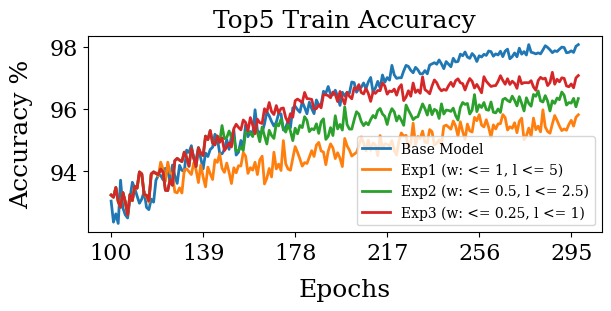

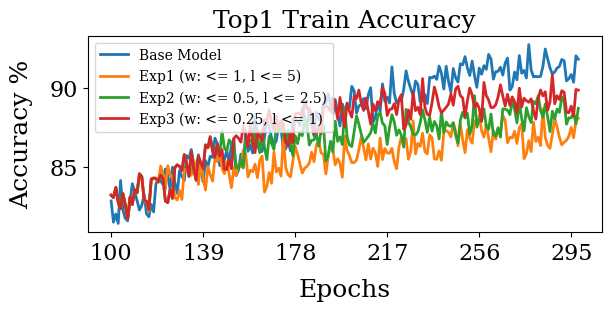

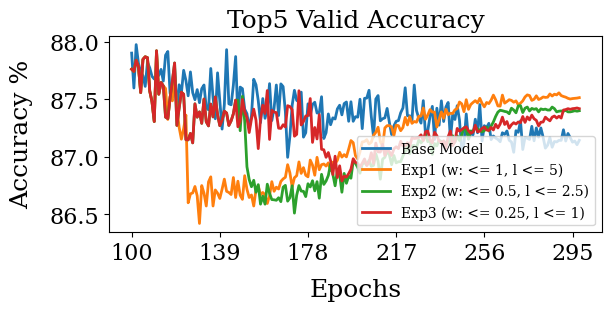

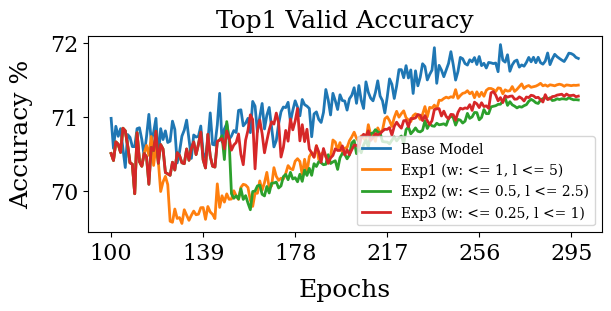

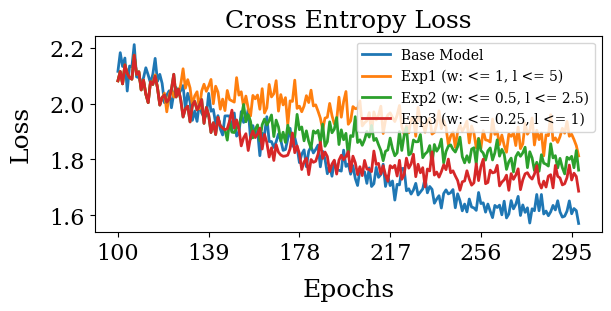

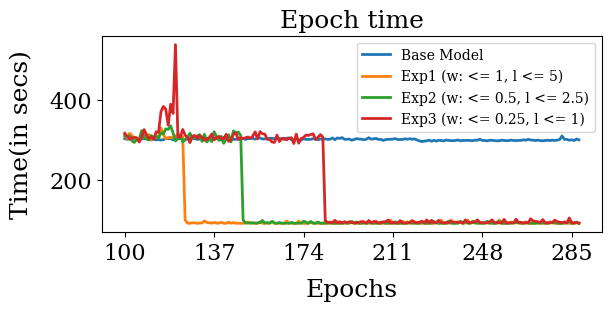

In [453]:
plot_values(train_top5_all, exp_1_full_train_t5, exp_2_full_train_t5, exp_4_full_train_t5, "Accuracy %", "Top5 Train Accuracy", "abl_top5_train")
plot_values(train_top1_all, exp_1_full_train_t1, exp_2_full_train_t1, exp_4_full_train_t1, "Accuracy %", "Top1 Train Accuracy", "abl_top1_train", 100)
plot_values(valid_top5_all, exp_1_full_valid_t5, exp_2_full_valid_t5, exp_4_full_valid_t5, "Accuracy %", "Top5 Valid Accuracy", "abl_top5_valid")
plot_values(valid_top1_all, exp_1_full_valid_t1, exp_2_full_valid_t1, exp_4_full_valid_t1, "Accuracy %", "Top1 Valid Accuracy", "abl_top1_valid", 100)
plot_values(train_loss_all, exp_1_full_loss, exp_2_full_loss, exp_4_full_loss, "Loss", "Cross Entropy Loss", "abl_loss")
plot_values(remove_outlier(train_epoch_time_all), remove_outlier(exp_1_full_epoch_time), remove_outlier(exp_2_full_epoch_time), remove_outlier(exp_4_full_epoch_time), "Time(in secs)", "Epoch time", "abl_epoch")


In [454]:
def plot_warmup_values(base, exp_1, exp_2, exp_3, y_label, title= "", start_epoch=125, filename="", draw_line=False):
    # Determine minimum length after start_epoch
    min_len = min(len(base) - start_epoch,
                  len(exp_1) - start_epoch,
                  len(exp_2) - start_epoch,
                  len(exp_3) - start_epoch)
    
    # X-axis values reflect actual epochs
    x = range(start_epoch, start_epoch + min_len)

    fig,ax = plt.subplots(figsize=(5,3), constrained_layout=True)

    ax.plot(x, base[start_epoch:start_epoch+min_len], label="Base", linewidth=2)
    ax.plot(x, exp_2[start_epoch:start_epoch+min_len], label="5", linewidth=2)
    ax.plot(x, exp_1[start_epoch:start_epoch+min_len], label="10", linewidth=2)
    ax.plot(x, exp_3[start_epoch:start_epoch+min_len], label="15", linewidth=2)

    ax.set_xlabel("Epochs", fontsize=18)
    ax.set_title(f"{title}", fontsize=18)
    ax.set_ylabel(f"{y_label}", fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.legend(loc="lower right")
    
    if draw_line:
        ax.axvline(x=141, color='gray', linestyle='--', linewidth=2)
        ax.axvline(x=160, color='gray', linestyle='--', linewidth=2)

    plt.show()

    fig.savefig(f"{filename}.pdf")  # keep consistent width

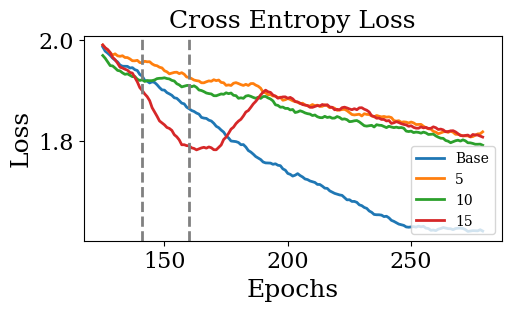

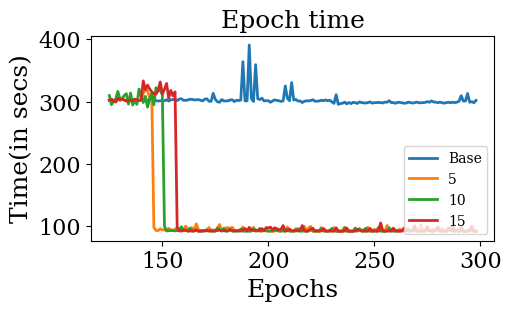

In [455]:
def moving_average(arr, window=20):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

# plot_warmup_values(moving_average(train_top1_all), moving_average(exp_2_full_train_t1), moving_average(exp_5_full_train_t1), moving_average(exp_6_full_train_t1), "Accuracy %", "Top1 Train Accuracy")
# plot_warmup_values(moving_average(valid_top1_all), moving_average(exp_2_full_valid_t1), moving_average(exp_5_full_valid_t1), moving_average(exp_6_full_valid_t1), "Accuracy %", "Top1 Valid Accuracy")
plot_warmup_values(moving_average(train_loss_all), moving_average(exp_2_full_loss), moving_average(exp_5_full_loss), moving_average(exp_6_full_loss), "Loss", "Cross Entropy Loss", 125,'warmup_loss', draw_line = True)
plot_warmup_values(train_epoch_time_all, exp_2_full_epoch_time, exp_5_full_epoch_time, exp_6_full_epoch_time, "Time(in secs)", "Epoch time",125,'warmup_speedup', draw_line= False)

# plot_warmup_values(remove_outlier(train_epoch_time_all[120:]), remove_outlier(exp_2_full_epoch_time[120:]), remove_outlier(exp_5_full_epoch_time[120:]), remove_outlier(exp_6_full_epoch_time[120:]), "Time(in secs)", "Epoch time")


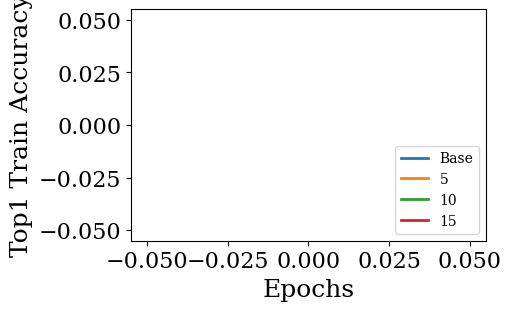

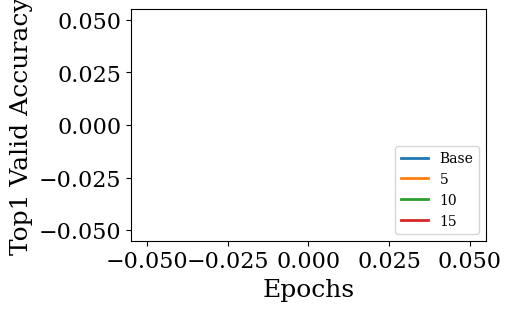

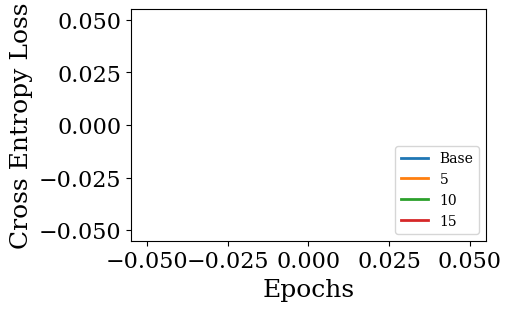

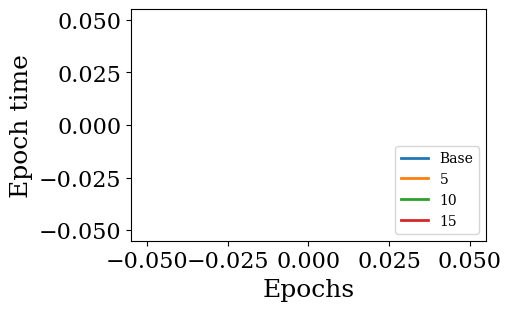

In [456]:
# plot_warmup_values(moving_average(exp_2_full_train_t5[135:]), moving_average(exp_5_full_train_t5[135:]), moving_average(exp_6_full_train_t5[135:]), "Accuracy %", "Top5 Train Accuracy")
plot_warmup_values(moving_average(exp_2_full_train_t1[135:]), moving_average(exp_5_full_train_t1[135:]), moving_average(exp_6_full_train_t1[135:]), "Accuracy %", "Top1 Train Accuracy")
# plot_warmup_values(moving_average(exp_2_full_valid_t5[135:]), moving_average(exp_5_full_valid_t5[135:]), moving_average(exp_6_full_valid_t5[135:]), "Accuracy %", "Top5 Valid Accuracy")
plot_warmup_values(moving_average(exp_2_full_valid_t1[135:]), moving_average(exp_5_full_valid_t1[135:]), moving_average(exp_6_full_valid_t1[135:]), "Accuracy %", "Top1 Valid Accuracy")
plot_warmup_values(moving_average(exp_2_full_loss[135:]), moving_average(exp_5_full_loss[135:]), moving_average(exp_6_full_loss[135:]), "Loss", "Cross Entropy Loss")
plot_warmup_values(remove_outlier(exp_2_full_epoch_time[135:]), remove_outlier(exp_5_full_epoch_time[135:]), remove_outlier(exp_6_full_epoch_time[135:]), "Time(in secs)", "Epoch time")


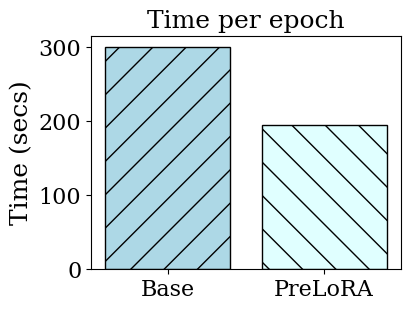

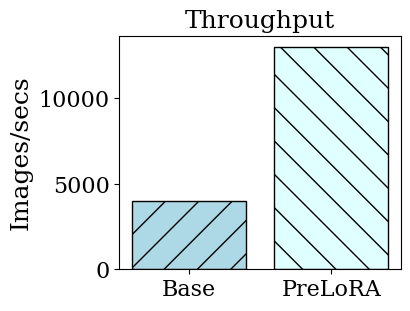

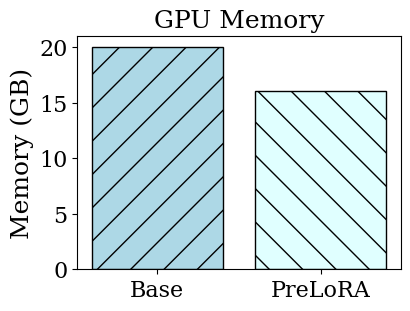

In [457]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

# Categories and hatch patterns
categories = ['Base', 'PreLoRA']
hatches = ['/', '\\']  # '/' for Before, '\' for After

# Function to create a styled bar chart
def plot_bar_chart(values, title, y_label, colors, filename):
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)  # assign to fig
    bars = ax.bar(categories, values, color=colors, edgecolor='black')
    
    # Apply consistent hatch patterns
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
        
    # Styling
    ax.set_ylabel(y_label, fontsize=18)
    ax.set_title(title, fontsize=18)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    
    # Save first, then show
    fig.savefig(f"{filename}.pdf", bbox_inches='tight')  # save correctly
    plt.show()  # display
    plt.close(fig)  # close to free memory

    

# 1. Epoch Time (secs) - light blue
plot_bar_chart([300, 195], "Time per epoch", "Time (secs)", ['lightblue','lightcyan'], 'time')

# 2. Training Images per Epoch - light orange
plot_bar_chart([4000, 13000], "Throughput", "Images/secs", ['lightblue','lightcyan'], 'compute')

# 3. GPU Memory (GB) - light green
plot_bar_chart([20, 16], "GPU Memory", "Memory (GB)", ['lightblue','lightcyan'], 'memory')


In [458]:
Query_lora_a_6 = [1.6972687989473343, 1.7186543097098668, 1.731484775741895, 1.7346957723299663, 1.8159462660551071, 1.9576841096083324, 2.064976066350937, 2.1409024596214294, 2.201176722844442, 2.2476640244325004, 2.2839211324850717, 2.3098058005174003, 2.3367804288864136, 2.356085697809855, 2.3722629447778067, 2.387389818827311, 2.399496744076411, 2.410061945517858, 2.4168176452318826, 2.4224061568578086, 2.427352080742518, 2.4304531117280326, 2.4332782526810965, 2.4358708262443542, 2.43789941072464, 2.43892494837443, 2.4402908186117807, 2.441736896832784, 2.4424730439980826, 2.44305553038915, 2.4432418843110404, 2.443413476149241, 2.4434434274832406]
Query_lora_b_6 = [0.560565368582805, 0.7215295732021332, 0.8267416755358378, 0.8463878805438677, 1.0178662637869518, 1.2621978720029194, 1.4345402419567108, 1.5501162707805634, 1.639745185772578, 1.7107804516951244, 1.7662353614966075, 1.8084917664527893, 1.8481692870457966, 1.877824400862058, 1.9016455709934235, 1.921526735027631, 1.9379145254691441, 1.952607348561287, 1.961931586265564, 1.969883109132449, 1.9765085230271022, 1.9812825719515483, 1.9848151157299678, 1.9881285727024078, 1.9905539751052856, 1.9918108234802883, 1.99318894247214, 1.994644656777382, 1.995171884695689, 1.9956150203943253, 1.9957749942938487, 1.9958995232979457, 1.9959228138128917]
Value_lora_a_6 = [1.5938931951920192, 1.5653259009122849, 1.5471789787213008, 1.544450004895528, 1.6924098978439968, 1.9059239278237026, 2.0603282948335013, 2.1701809416214624, 2.250681683421135, 2.3131698866685233, 2.362441658973694, 2.4031257728735604, 2.438129261136055, 2.4661960999170938, 2.486940105756124, 2.5099302579959235, 2.525935724377632, 2.5393340239922204, 2.5492285887400308, 2.5580382545789084, 2.5662802259127298, 2.5724660803874335, 2.577862416704496, 2.5818828692038855, 2.5853960116704306, 2.5879478603601456, 2.589669495820999, 2.5910943349202475, 2.5920306344827018, 2.592709352572759, 2.5929924746354422, 2.5932082682847977, 2.5932364265124]
Value_lora_b_6 = [0.45016389588514966, 0.5674651823937893, 0.648425911863645, 0.6632469668984413, 0.9385735715428988, 1.242714285850525, 1.4431212544441223, 1.5855547388394673, 1.6911775022745132, 1.7726679543654125, 1.8379376133282979, 1.8927898854017258, 1.9413192172845204, 1.9787368029356003, 2.0071688344081244, 2.0353880574305854, 2.0569747537374496, 2.076089635491371, 2.0887805968523026, 2.1011881232261658, 2.1122442930936813, 2.1200854927301407, 2.1267981827259064, 2.131922115882238, 2.136346936225891, 2.139567310611407, 2.141049404939016, 2.1423524667819343, 2.1431965231895447, 2.1438226203123727, 2.1440868029991784, 2.1442902237176895, 2.1443152725696564]
Dense_lora_a_6 = [1.7439547495709524, 1.7929074317216873, 1.821434948179457, 1.8266419139173296, 1.988250732421875, 2.223591690262159, 2.413708112306065, 2.5595506727695465, 2.675213744242986, 2.765562559167544, 2.840148212181197, 2.90042198366589, 2.952558681368828, 2.992013250788053, 3.0240121798382864, 3.0543636083602905, 3.0776941064331265, 3.0980574041604996, 3.1144320285982556, 3.127141354812516, 3.139082839091619, 3.1485073467095694, 3.156558526886834, 3.162814153565301, 3.1677048007647195, 3.171598215897878, 3.1733734475241766, 3.175244818131129, 3.1764368563890457, 3.177283489041858, 3.1775912758376865, 3.1778584635919995, 3.1778939647807016]
Dense_lora_b_6 = [0.7041283672054609, 0.9057372357282374, 1.0346784757243261, 1.0571872856881883, 1.3311837886770566, 1.6492788659201727, 1.881330344412062, 2.055130688680543, 2.1943693227238126, 2.301752441459232, 2.389996616376771, 2.4610515021615558, 2.5220111823744245, 2.5691328661309347, 2.6070928143130407, 2.6414519763655133, 2.668350213103824, 2.6912731677293777, 2.7088975608348846, 2.723226300544209, 2.7357697006728916, 2.74551189939181, 2.7536501387755075, 2.759851829873191, 2.7645177096128464, 2.7681237111488977, 2.7697794669204288, 2.7713176591528788, 2.7722561111052832, 2.77288681268692, 2.77310630844699, 2.773320762647523, 2.773349473873774]

In [459]:
Query_lora_a_5 = [1.6972687989473343, 1.6979011446237564, 1.8748593131701152, 2.064478114247322, 2.1911465724309287, 2.27933402856191, 2.3461367587248483, 2.394958645105362, 2.4351672530174255, 2.468704015016556, 2.49561200539271, 2.5142164826393127, 2.5311228732268014, 2.5468625724315643, 2.556009848912557, 2.5660514533519745, 2.5760367810726166, 2.582824488480886, 2.587720731894175, 2.592742015918096, 2.595852702856064, 2.599069039026896, 2.60021318991979, 2.6018741925557456, 2.6032533248265586, 2.605794300635656, 2.6075348953406015, 2.609119991461436, 2.6099834938844046, 2.6105914413928986, 2.610754817724228, 2.6109197239081063, 2.610943526029587]
Query_lora_b_5 = [0.560565368582805, 0.5670546690622965, 0.9551407148440679, 1.2792391031980515, 1.482246031363805, 1.6215011874834697, 1.7224564601977665, 1.797941158215205, 1.8644666870435078, 1.9177827835083008, 1.9611493746439617, 1.994138280550639, 2.0209417939186096, 2.0471939394871392, 2.0641230742136636, 2.080546259880066, 2.094927911957105, 2.105385551850001, 2.1132623851299286, 2.120127489169439, 2.1245934814214706, 2.129610911011696, 2.132663240035375, 2.135103623072306, 2.1362331410249076, 2.1388377944628396, 2.140599012374878, 2.1422914465268454, 2.1431075632572174, 2.143676390250524, 2.143844097852707, 2.1439853509267173, 2.1440055072307587]
Value_lora_a_5 = [1.5938931951920192, 1.5930322657028835, 1.847472091515859, 2.1047180543343225, 2.2627822210391364, 2.3762129147847495, 2.4580618341763816, 2.5123132169246674, 2.559754490852356, 2.599786122639974, 2.634344140688578, 2.657928536335627, 2.6791336139043174, 2.69860049088796, 2.7144502997398376, 2.7285871704419455, 2.74097016453743, 2.7516231735547385, 2.759962340195974, 2.7676157653331757, 2.7732225954532623, 2.7774175703525543, 2.7810501952966056, 2.7846138775348663, 2.786742478609085, 2.789175361394882, 2.791543334722519, 2.7931914031505585, 2.794314722220103, 2.795022596915563, 2.795213669538498, 2.7954165438810983, 2.7954466342926025]
Value_lora_b_5 = [0.45016389588514966, 0.45517318447430927, 0.9464717656373978, 1.2985375424226124, 1.511995534102122, 1.6746720323959987, 1.7879350632429123, 1.87114184598128, 1.9427790641784668, 2.0048404137293496, 2.058691680431366, 2.0949059277772903, 2.1284072200457254, 2.1587553322315216, 2.1841037968794503, 2.2049176494280496, 2.224249745408694, 2.239691987633705, 2.252285599708557, 2.262941285967827, 2.271178498864174, 2.2768797626098, 2.282811606923739, 2.287636786699295, 2.289733275771141, 2.2921148538589478, 2.2943398555119834, 2.295781741539637, 2.296837786833445, 2.2975203345219293, 2.297702064116796, 2.297865927219391, 2.297893320520719]
Dense_lora_a_5 = [1.7439547495709524, 1.7461493992143207, 2.0571623428000345, 2.3799893425570593, 2.6094599614540734, 2.774897593590948, 2.901998413933648, 2.994943921764692, 3.0720098084873624, 3.1355098618401422, 3.189198033677207, 3.2295966893434525, 3.2648147112793393, 3.2966322981648974, 3.320303517911169, 3.340348766909705, 3.359397797120942, 3.373789163099395, 3.385053710805045, 3.3951125078731113, 3.4035403579473495, 3.4101241098509893, 3.4161464936203427, 3.421235697136985, 3.423332166340616, 3.42607084247801, 3.428412722216712, 3.4301122989919453, 3.4312245696783066, 3.432046451502376, 3.4322121524148517, 3.4324370390839047, 3.4324724508656397]
Dense_lora_b_5 = [0.7041283672054609, 0.7123665581974719, 1.2552047040727403, 1.6594850222269695, 1.9379592405425177, 2.1440781503915787, 2.3023647715648017, 2.4201927897002964, 2.519342612889078, 2.6003302517864437, 2.6669599960247674, 2.7186699128813214, 2.7637251681751676, 2.802803655465444, 2.8322531746493445, 2.8574428823259144, 2.880795200665792, 2.8984598418076835, 2.9115837862094245, 2.9232243912087545, 2.932753915588061, 2.9399064630270004, 2.9462005777491465, 2.9512296865383782, 2.9533278395732245, 2.9555411818954678, 2.957379690474934, 2.9587132996983, 2.9595420493019953, 2.960180774331093, 2.9602904038296805, 2.9604669875568814, 2.9604935265249677]

In [460]:
Query_lora_a_3 = [1.694082240263621, 1.7190613051255543, 1.720139776666959, 1.8595753858486812, 2.017507935563723, 2.125238448381424, 2.2062791685263314, 2.2664458552996316, 2.3144536713759103, 2.3516694406668344, 2.383507897456487, 2.4084628323713937, 2.4305651585261026, 2.4468746185302734, 2.4615284899870553, 2.473472019036611, 2.4829853773117065, 2.4901641507943473, 2.4966616133848825, 2.5015163322289786, 2.506350894769033, 2.51019357641538, 2.5128730734189353, 2.514204372962316, 2.515892207622528, 2.517388035853704, 2.5190330346425376, 2.520230064789454, 2.521214703718821, 2.521658976872762, 2.521762321392695, 2.521917055050532, 2.5219365855058036]
Query_lora_b_3 = [0.5554388128221035, 0.7229757333795229, 0.7336609040697416, 1.0241840407252312, 1.2944574256738026, 1.4694712609052658, 1.5943549821774166, 1.6887659678856533, 1.7602422734101613, 1.8160854329665501, 1.8645670811335247, 1.9029707858959835, 1.9350929409265518, 1.9616297880808513, 1.983159417907397, 2.0022015819946923, 2.0168571025133133, 2.0276323656241098, 2.0375106930732727, 2.044090767701467, 2.0507423828045526, 2.0555476446946463, 2.058615336815516, 2.0602392653624215, 2.0618244856595993, 2.0633059243361154, 2.064979463815689, 2.066046526034673, 2.066939060886701, 2.0673411140839257, 2.067411040266355, 2.0675326188405356, 2.067551220456759]
Value_lora_a_3 = [1.5895926902691524, 1.5657023439804714, 1.5647008170684178, 1.7797886927922566, 2.003262663880984, 2.154761036237081, 2.2632660319407782, 2.34646674990654, 2.408277213573456, 2.45832925538222, 2.4979631354411445, 2.534078468879064, 2.559401045242945, 2.5825238625208535, 2.601820945739746, 2.619155635436376, 2.6321986814339957, 2.6433603962262473, 2.653378407160441, 2.6623611946900687, 2.6705234249432883, 2.676694333553314, 2.6804964939753213, 2.684083710114161, 2.687064598004023, 2.6887289683024087, 2.690751850605011, 2.6923601428667703, 2.693556229273478, 2.694190581639608, 2.694378445545832, 2.694544712702433, 2.694564243157705]
Value_lora_b_3 = [0.44217679649591446, 0.5702087270716826, 0.5796781405806541, 0.9796453267335892, 1.2872955203056335, 1.4864939351876576, 1.6293814877669017, 1.7384197066227596, 1.822056382894516, 1.8911645362774532, 1.9471672823031743, 1.9982441167036693, 2.035581573843956, 2.068123151858648, 2.0936378091573715, 2.116821140050888, 2.134733274579048, 2.1503780533870063, 2.164048353830973, 2.175662025809288, 2.185969283183416, 2.1947606652975082, 2.199753373861313, 2.204519068201383, 2.20817702015241, 2.209832121928533, 2.2116513748963675, 2.2131723215182624, 2.2142217556635537, 2.214806154370308, 2.2149839103221893, 2.2151304384072623, 2.215146909157435]
Dense_lora_a_3 = [1.7371039870712492, 1.7924925453133054, 1.7965184168683157, 2.0434368269311056, 2.31196661790212, 2.5125732355647616, 2.6652881105740867, 2.787033814522955, 2.880274330576261, 2.9555484884315066, 3.0188207907809153, 3.0689517905314765, 3.1120766169495053, 3.1458952162000866, 3.174876122011079, 3.20125585132175, 3.222414511773321, 3.238403800461027, 3.2540745271576776, 3.265910049279531, 3.2765880624453225, 3.2858539323012033, 3.2921176883909435, 3.2970267948177128, 3.3011975073152118, 3.3034201198154025, 3.3057613174120584, 3.307663737071885, 3.309013416369756, 3.3097594330708184, 3.30997473332617, 3.3101897885402045, 3.3102154036362967]
Dense_lora_b_3 = [0.6973717618319724, 0.905349420176612, 0.9198646280500624, 1.3424042024546199, 1.6873671925730176, 1.9326194094287024, 2.1164241234461465, 2.2623549467987485, 2.374534398317337, 2.4660032805469303, 2.5416997422774634, 2.602851101093822, 2.6548104319307537, 2.6954482512341604, 2.7288468099302716, 2.7591929187377295, 2.783697424663438, 2.8019172896941504, 2.8188293129205704, 2.8315560503138437, 2.8429155068265066, 2.852232446273168, 2.8584531247615814, 2.863035057981809, 2.8672088334957757, 2.8690976914432316, 2.8709800193707147, 2.8724046498537064, 2.873400969637765, 2.8739324791563883, 2.8740615480475955, 2.874227225780487, 2.8742466320594153]

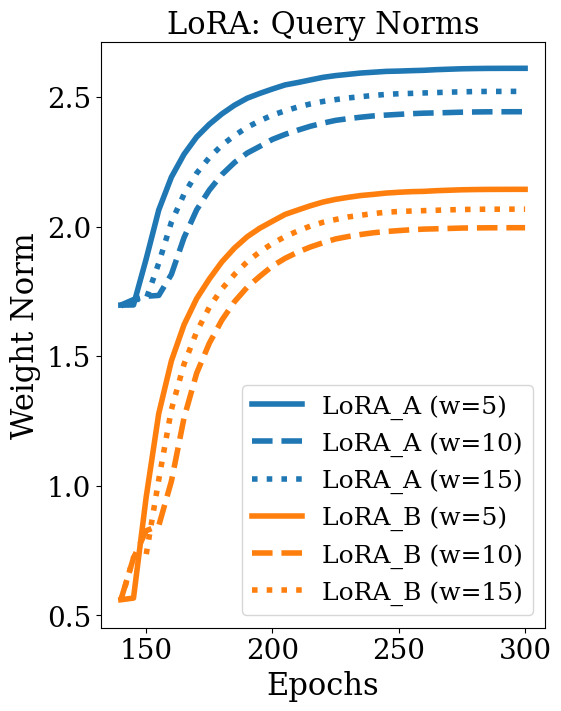

In [493]:
import matplotlib.pyplot as plt

# Data for Exp 5, 6, 3
exp5_data = {
    "Query_lora_A": Query_lora_a_5,
    "Query_lora_B": Query_lora_b_5,
    "Value_lora_A": Value_lora_a_5,
    "Value_lora_B": Value_lora_b_5,
    "Dense_lora_A": Dense_lora_a_5,
    "Dense_lora_B": Dense_lora_b_5
}

exp6_data = {
    "Query_lora_A": Query_lora_a_6,
    "Query_lora_B": Query_lora_b_6,
    "Value_lora_A": Value_lora_a_6,
    "Value_lora_B": Value_lora_b_6,
    "Dense_lora_A": Dense_lora_a_6,
    "Dense_lora_B": Dense_lora_b_6
}

exp3_data = {
    "Query_lora_A": Query_lora_a_3,
    "Query_lora_B": Query_lora_b_3,
    "Value_lora_A": Value_lora_a_3,
    "Value_lora_B": Value_lora_b_3,
    "Dense_lora_A": Dense_lora_a_3,
    "Dense_lora_B": Dense_lora_b_3
}

modules = ["Query"]

# Use constrained layout
fig, axes = plt.subplots(1, len(modules), figsize=(5.5, 7), constrained_layout=True)

for i, module in enumerate(modules):
    ax = axes[i] if len(modules) > 1 else axes
    num_points = len(exp5_data[f"{module}_lora_A"])
    
    # LoRA_A plots
    ax.plot([140 + 5* idx for idx in range(num_points)], exp5_data[f"{module}_lora_A"], label=f"LoRA_A (w=5)", color='tab:blue', linestyle='-', linewidth=4)
    ax.plot([140 + 5* idx for idx in range(num_points)], exp6_data[f"{module}_lora_A"], label=f"LoRA_A (w=10)", color='tab:blue', linestyle='--', linewidth=4)
    ax.plot([140 + 5* idx for idx in range(num_points)], exp3_data[f"{module}_lora_A"], label=f"LoRA_A (w=15)", color='tab:blue', linestyle=':', linewidth=4)
    
    # LoRA_B plots
    ax.plot([140 + 5* idx for idx in range(num_points)], exp5_data[f"{module}_lora_B"], label=f"LoRA_B (w=5)", color='tab:orange', linestyle='-', linewidth=4)
    ax.plot([140 + 5* idx for idx in range(num_points)], exp6_data[f"{module}_lora_B"], label=f"LoRA_B (w=10)", color='tab:orange', linestyle='--', linewidth=4)
    ax.plot([140 + 5* idx for idx in range(num_points)], exp3_data[f"{module}_lora_B"], label=f"LoRA_B (w=15)", color='tab:orange', linestyle=':', linewidth=4)
    
    ax.set_title(f"LoRA: {module} Norms", fontsize=22)
    ax.set_xlabel("Epochs", fontsize=22)
    ax.set_ylabel("Weight Norm", fontsize=22)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.legend(fontsize=18, loc="lower right", ncol=1)
    ax.grid(False)

# Save **before** showing
plt.savefig("query_lora_norms.pdf")
plt.show()


In [462]:
Query_5 = [22.669706501066685, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162, 22.673580671350162]
Value_5 = [23.36958802677691, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417, 23.373731669659417]
Dense_5 = [41.13215787708759, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086, 41.137497694128086]

In [463]:
Query_6 = [22.669706501066685, 22.779536900420982, 22.87033541003863, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124, 22.886477301518124]
Value_6 = [23.36958802677691, 23.48336814219753, 23.57698831707239, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346, 23.59669323824346]
Dense_6 = [41.13215787708759, 41.28197939445575, 41.394408601439665, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115, 41.414909289115]

In [464]:
Query_3 = [22.667753954728443, 22.778313634296257, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795, 22.788755387067795]
Value_3 = [23.361986154690385, 23.479691101859014, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267, 23.489027297124267]
Dense_3 = [41.13098492183619, 41.27824254996247, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333, 41.28910132580333]

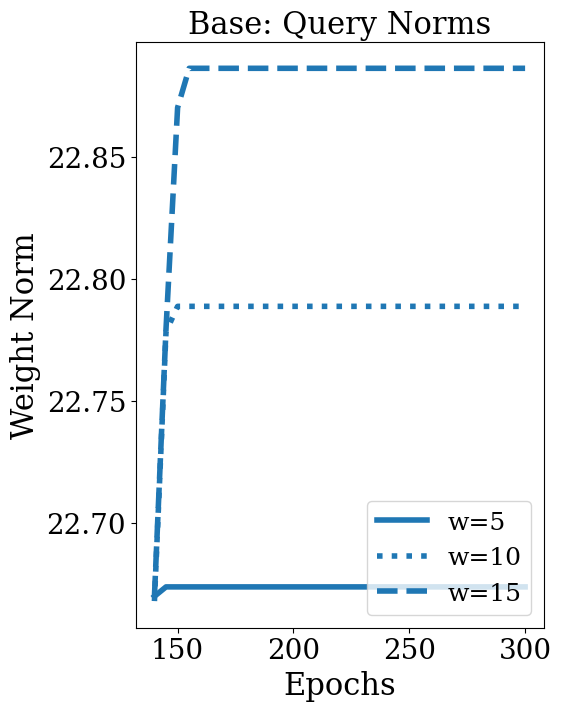

In [494]:
# Layer-wise norms for Exp5 and Exp6
exp5_data = {
    "Query": Query_5,
    "Value": Value_5,
    "Dense": Dense_5,
}

exp6_data = {
    "Query": Query_6,
    "Value": Value_6,
    "Dense": Dense_6,
}

exp3_data = {
    "Query": Query_3,
    "Value": Value_3,
    "Dense": Dense_3,
}

modules = ["Query"]

fig, axes = plt.subplots(figsize=(5.5, 7), constrained_layout=True)

for i, module in enumerate(modules):
    ax = axes[i] if len(modules) > 1 else axes
    num_points = len(exp5_data[module])
    
    ax.plot([140 + 5* index for index in range(num_points)], exp5_data[module], label=f"w=5", color='tab:blue', linestyle='-', linewidth=4)
    ax.plot([140 + 5* index for index in range(num_points)], exp3_data[module], label=f"w=10", color='tab:blue', linestyle=':', linewidth=4)
    ax.plot([140 + 5* index for index in range(num_points)], exp6_data[module], label=f"w=15", color='tab:blue', linestyle='--', linewidth=4)

    ax.set_title(f"Base: {module} Norms", fontsize=22)
    ax.set_xlabel("Epochs", fontsize=22)
    ax.set_ylabel("Weight Norm", fontsize=22)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.legend(fontsize=18, loc="lower right")
    ax.grid(False)

plt.savefig("query_base_norms.pdf")
plt.show()



In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

# Categories and hatch patterns
categories = ['Base', 'PreLoRA']
hatches = ['/', '\\']  # '/' for Before, '\' for After
colors = ['#2E86AB', '#A23B72']  # Attractive blue and coral colors

# Create a single figure with 3 subplots arranged horizontally - narrower for single column
fig, axes = plt.subplots(1, 3, figsize=(6, 2.5), constrained_layout=True)

# Data for each subplot
data = [
    ([300, 195], "Time per epoch", "Time (secs)"),
    ([4000, 13000], "Throughput", "Images/secs"),
    ([20, 16], "GPU Memory", "Memory (GB)")
]

# Plot each subplot
bars_list = []  # Store bars for legend
for i, (values, title, y_label) in enumerate(data):
    bars = axes[i].bar(categories, values, color=colors, edgecolor='black', width=0.7)
    bars_list.append(bars)
    
    # Apply consistent hatch patterns
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
        
    # Styling
    axes[i].set_ylabel(y_label, fontsize=14)
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xticks([])  # Remove x-axis labels
    axes[i].tick_params(axis='y', labelsize=12)

# Add legend to the top of the figure with more space
fig.legend(bars_list[0], categories, loc='upper center', bbox_to_anchor=(0.5, 1.25), 
           ncol=2, fontsize=12)

# Save the combined figure
fig.savefig("combined_metrics.pdf", bbox_inches='tight')
plt.show()
plt.close(fig)